In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse, very_small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_sROM, target_function, get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw, train_ROM_rw, snapshots_rowwise
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# tmeplate: X_randMU

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [4]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=1/45)


def small_rectangular_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.01)



In [5]:
n_x = 2500
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 50,
    "g": small_rectangular_pulse, #saw_tooth, #rectangular_pulse,small_r_pulse, small_saw_tooth, very_small_r_pulse
    "truncate": 12,
    "sigma": 0.08,

    "c": 0.0,
    "monitor_progress_postprocessing": False,
    "num_iter": 200,
    "monitor_convergence": False,
}

(0.1, 0.2)

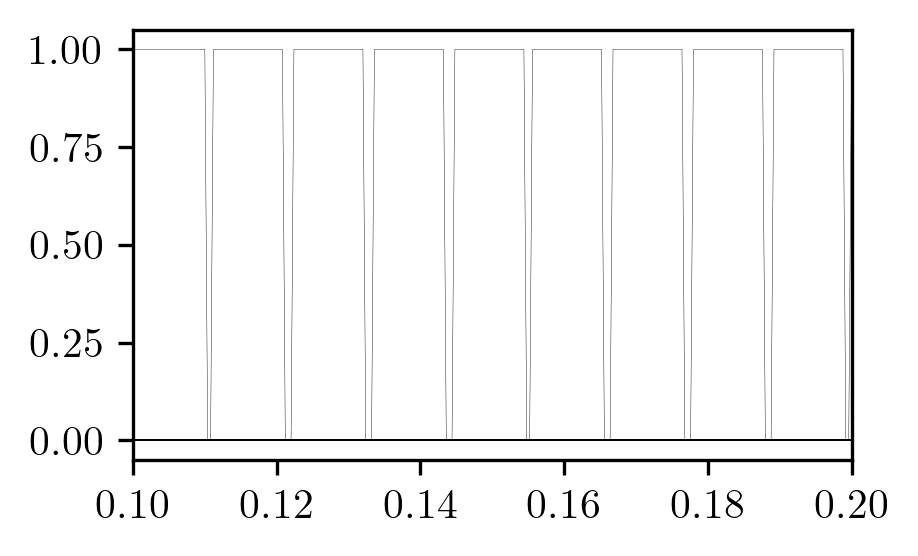

In [6]:
rank = 90
case["rank"] = case["n_train"] = n_train = rank

mu_train = np.linspace([0], [1], n_train, endpoint=False)


X_train, X_train_s = get_data_rw(mu_train, **case)
for i in range(len(X_train)):
    plt.plot(x, X_train[i], "k-", lw=.1)
plt.xlim(.1, .2)

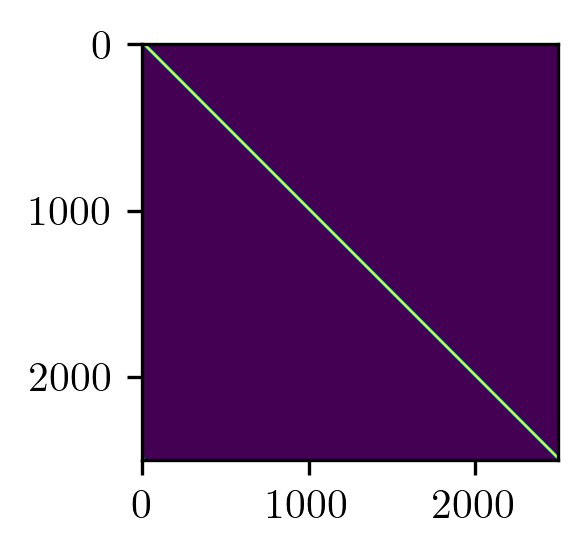

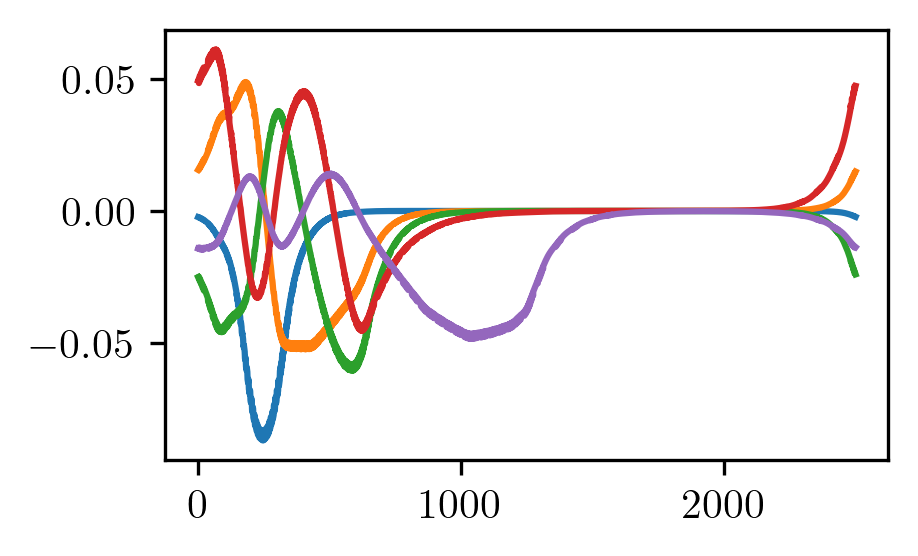

In [7]:
# https://stats.stackexchange.com/a/211693

X = snapshots_rowwise(small_rectangular_pulse, x, mu=np.linspace(0, 1, n_x, endpoint=False))
U, S, VT = np.linalg.svd(X.T, full_matrices=False)
a, b = X.shape
delta_n = (np.cumsum(S[::-1]**2)[::-1]/a/b)**.5
dN = delta_n

plt.imshow(X)
plt.show()

for i in range(5):
    plt.plot(U[:, i])

In [8]:
case["mu_test"] = np.random.rand(case["n_test"])[:, None]
del case["n_test"]
case["mu_test"]

array([[0.16287121],
       [0.87682279],
       [0.60426907],
       [0.31541268],
       [0.85904393],
       [0.26460554],
       [0.31387253],
       [0.86655567],
       [0.72934325],
       [0.47903826],
       [0.85440422],
       [0.3606668 ],
       [0.77001963],
       [0.41787331],
       [0.96429985],
       [0.28184523],
       [0.41938609],
       [0.34772036],
       [0.20415575],
       [0.57561102],
       [0.69154039],
       [0.48176308],
       [0.88912111],
       [0.40818162],
       [0.78645476],
       [0.01849889],
       [0.217393  ],
       [0.89015937],
       [0.09490195],
       [0.38558628],
       [0.29557243],
       [0.18889851],
       [0.87596789],
       [0.97427561],
       [0.84879949],
       [0.89267976],
       [0.11477027],
       [0.93124967],
       [0.67572323],
       [0.0352675 ],
       [0.8044554 ],
       [0.73457772],
       [0.99178405],
       [0.49791759],
       [0.85775852],
       [0.54437001],
       [0.38875075],
       [0.550

In [25]:
NN = np.array([3, *np.arange(10, 200, 20), *np.arange(200, 525, 25)])

[[0.16287121]
 [0.87682279]
 [0.60426907]
 [0.31541268]
 [0.85904393]
 [0.26460554]
 [0.31387253]
 [0.86655567]
 [0.72934325]
 [0.47903826]
 [0.85440422]
 [0.3606668 ]
 [0.77001963]
 [0.41787331]
 [0.96429985]
 [0.28184523]
 [0.41938609]
 [0.34772036]
 [0.20415575]
 [0.57561102]
 [0.69154039]
 [0.48176308]
 [0.88912111]
 [0.40818162]
 [0.78645476]
 [0.01849889]
 [0.217393  ]
 [0.89015937]
 [0.09490195]
 [0.38558628]
 [0.29557243]
 [0.18889851]
 [0.87596789]
 [0.97427561]
 [0.84879949]
 [0.89267976]
 [0.11477027]
 [0.93124967]
 [0.67572323]
 [0.0352675 ]
 [0.8044554 ]
 [0.73457772]
 [0.99178405]
 [0.49791759]
 [0.85775852]
 [0.54437001]
 [0.38875075]
 [0.55003768]
 [0.93320808]
 [0.59538014]]
3


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 28, 0.06400000, 1.00000000, 0.12889729, 0.09889523, 0.10448118, -18.9423
0.3909177216847635 0.4129981434381487
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 28, 0.03200000, 1.00000000, 0.12889729, 0.10026567, 0.11235357, -12.8348
0.5605021454061352 0.628075569181004
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 28, 0.01600000, 1.00000000, 0.12889729, 0.10344304, 0.12419260, -3.6500
0.8177890436322558 0.9818287051367599
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 28, 0.00800000, 1.00000000, 0.12889729, 0.10958221, 0.13377486, 3.7841
1.2251663962330839 1.4956484370726921
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 28, 0.00400000, 1.00000000, 0.12889729, 0.11716964, 0.136431

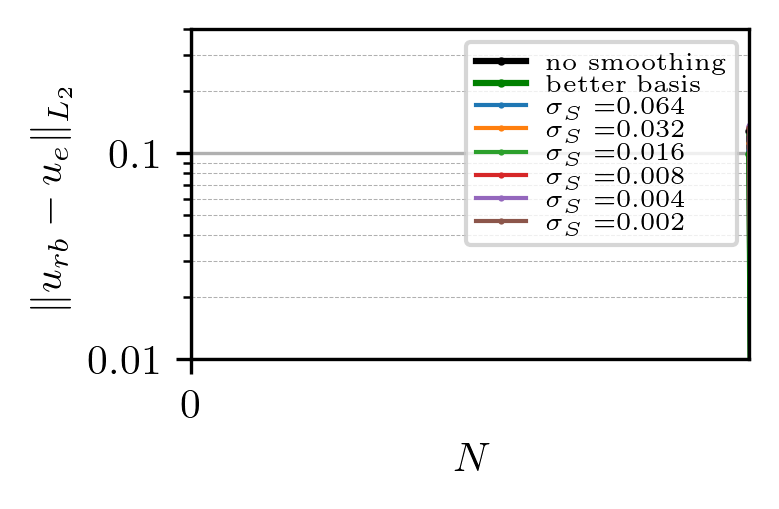

10


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 10, 45, 0.06400000, 1.00000000, 0.12166626, 0.09649647, 0.08573225, -29.5349
0.38143580026916807 0.3388864697907556
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 10, 45, 0.03200000, 1.00000000, 0.12166626, 0.09491229, 0.09704714, -20.2350
0.5305758275023394 0.5425099879897034
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 10, 45, 0.01600000, 1.00000000, 0.12166626, 0.09512799, 0.11505869, -5.4309
0.7520528071935801 0.9096188194775422
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 10, 45, 0.00800000, 1.00000000, 0.12166626, 0.09934817, 0.12540118, 3.0698
1.1107463400869488 1.4020278006980045
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 10, 45, 0.00400000, 1.00000000, 0.12166626, 0.10738365, 0

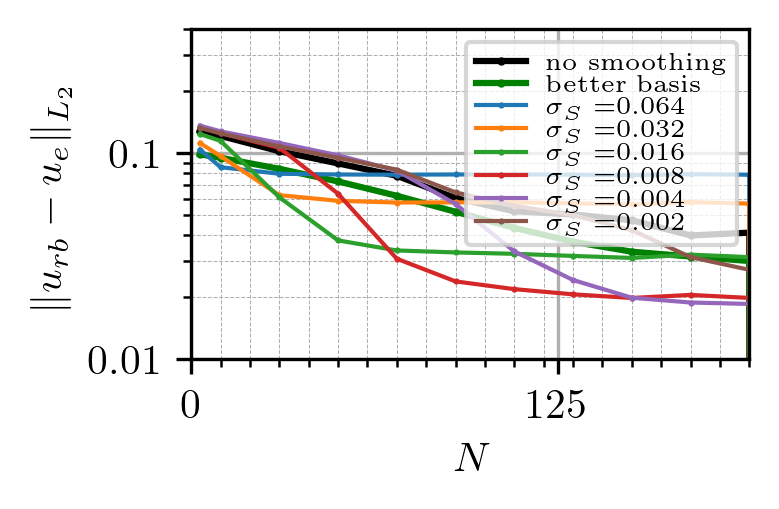

200


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 200, 50, 0.06400000, 1.00000000, 0.03765718, 0.09589851, 0.07938218, 110.8022
0.379072146128509 0.3137856063678663
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 200, 50, 0.03200000, 1.00000000, 0.03765718, 0.09169252, 0.05818862, 54.5220
0.5125767431746294 0.3252842846320094
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 200, 50, 0.01600000, 1.00000000, 0.03765718, 0.08321609, 0.03230152, -14.2221
0.6578809305713569 0.25536596299920256
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 200, 50, 0.00800000, 1.00000000, 0.03765718, 0.06763160, 0.02052216, -45.5027
0.7561442307274114 0.22944473037697502
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 200, 50, 0.00400000, 1.00000000, 0.03765718, 0.0479

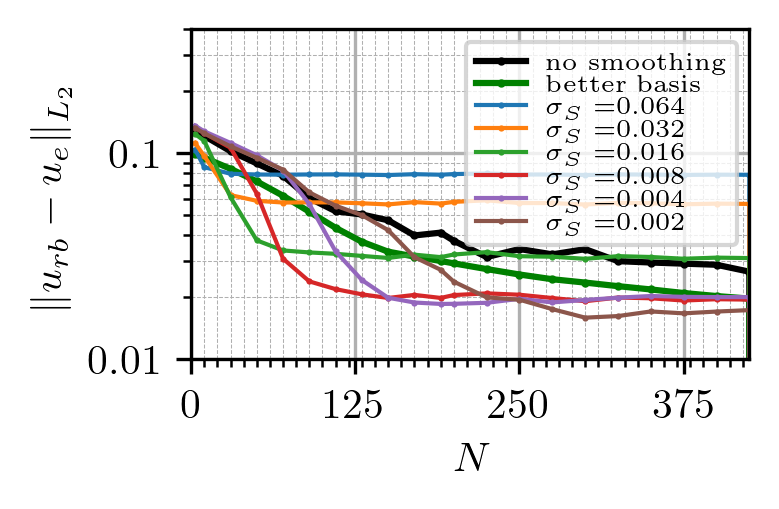

450


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 450, 50, 0.06400000, 1.00000000, 0.02199207, 0.09589695, 0.07991078, 263.3618
0.37906599386416756 0.31587510807741487
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 450, 50, 0.03200000, 1.00000000, 0.02199207, 0.09167982, 0.05916861, 169.0452
0.51250577102986 0.3307625680009392
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 450, 50, 0.01600000, 1.00000000, 0.02199207, 0.08311480, 0.03298993, 50.0083
0.6570801600626317 0.26080828921956567
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 450, 50, 0.00800000, 1.00000000, 0.02199207, 0.06694392, 0.02062873, -6.1993
0.7484557935459601 0.23063618463498214
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 450, 50, 0.00400000, 1.00000000, 0.02199207, 0.0454

In [9]:
g = case["g"]
mu_test = case["mu_test"].copy()
print(mu_test)
shape = case["shape"]
num_iter1 = 100
num_iter2 = 250
num_iter = num_iter2
case["c"] = 1

NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
#NN = np.array([3, *np.arange(10, 200, 20), *np.arange(200, 525, 25)])
#NN = np.array([500])  # np.array([100, 150, 250, 350, 500])
#NN = np.array([3, 50, 100, 250, 500])
#NN = np.array([*np.arange(10, 30, 2), 50, 100, 200, 300, 400, 500])
dN_ROM = np.zeros(len(NN))
dN_ROMi = np.zeros(len(NN))

sig = [0.0025, 0.01]
sig = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])
#sig = np.array([0.032, 0.008])
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

dN_sig_sROM = np.zeros((len(NN), len(sig)))
dN_sig_dsROM = np.zeros((len(NN), len(sig)))
for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    case["num_iter"] = num_iter
    case["rank"] = rank
    case["n_train"] = n_train
    case["sROM_only"] = False
    case["mu_test"] = mu_test.copy()
    in_range = mu_test[:, 0] < 1-1/rank
    case["mu_test"] = case["mu_test"][in_range, :]
    
    basis = U[:, :rank]
    X_test, _ = get_data_rw(mu_test, **case)
    X_test_ROMi = (basis @ (basis.T @ X_test.T)).T
    e_ROMi = L2_error_rw(X_test_ROMi, X_test)
    mean_ROMi = np.mean(e_ROMi)
    dN_ROMi[i] = mean_ROMi


    for j in range(len(sig)):
        case["sigma"] = sig[j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig_sROM[i, j] = mean_sROM
        dN_sig_dsROM[i, j] = mean_sROMs
        print(mean_sROM/sig[j]**.5, mean_sROMs/sig[j]**.5)
        
    dN_ROM[i] = mean_ROM
    if i % 10 == 0:
        fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))

        plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
        plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
        for j in range(len(sig)):
            plt.plot(NN, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
        #plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
        plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
        plt.xlabel(r"$N$")
        plt.legend()
        ax.set_yscale("log")
        plt.xlim(0, rank)
        plt.ylim(0.02, 0.2)
        ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
        ax.set_xticks([0, 125, 250, 375, 500], minor=False)
        ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
        ax.set_yticks([0.1, 0.01], minor=False)
        #ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
        plt.grid(True, which="minor", linestyle="--", lw=0.25)
        plt.grid(True, which="major", linestyle="-")
        ax.set_yticklabels(["0.1", "0.01"], minor=False)
        plt.xlim(0, rank)
        
        plt.show()


In [10]:
plateauS = dN_sig_sROM[i]
plateauDS = dN_sig_dsROM[i]
print(sig)
print(np.round(plateauS, decimals=3))
print(np.round(plateauDS, decimals=3))
print(np.round(plateauS/np.array(sig)**.5, decimals=3))
print(np.round(plateauDS/np.array(sig)**.5, decimals=3))

[0.064 0.032 0.016 0.008 0.004 0.002]
[0.096 0.092 0.083 0.067 0.045 0.032]
[0.079 0.057 0.032 0.02  0.021 0.019]
[0.379 0.512 0.657 0.748 0.719 0.716]
[0.312 0.321 0.25  0.228 0.326 0.423]


In [11]:
plateauS = dN_sig_sROM[i]
plateauDS = dN_sig_dsROM[i]
print(sig)
print(plateauS)
print(plateauDS)
print(plateauS/np.array(sig)**.5)
print(plateauDS/np.array(sig)**.5)

[0.064 0.032 0.016 0.008 0.004 0.002]
[0.0958934  0.09167273 0.08310197 0.06693256 0.04549899 0.03201501]
[0.07904451 0.05746272 0.03165093 0.0203507  0.02061972 0.01893168]
[0.37905196 0.51246616 0.65697872 0.74832879 0.71940216 0.71587736]
[0.31245084 0.32122636 0.25022256 0.22752773 0.32602646 0.42332513]


[0.064 0.032 0.016 0.008 0.004 0.002]

[0.08004655 0.07396857 0.06236488 0.04545092 0.03139018 0.02271016]

[0.06506673 0.04558852 0.03256524 0.0270865  0.0192637  0.01514171]

[0.31641175 0.41349686 0.4930377  0.50815671 0.49632234 0.50781458]

[0.25719882 0.2548476  0.25745082 0.30283626 0.30458579 0.33857894]

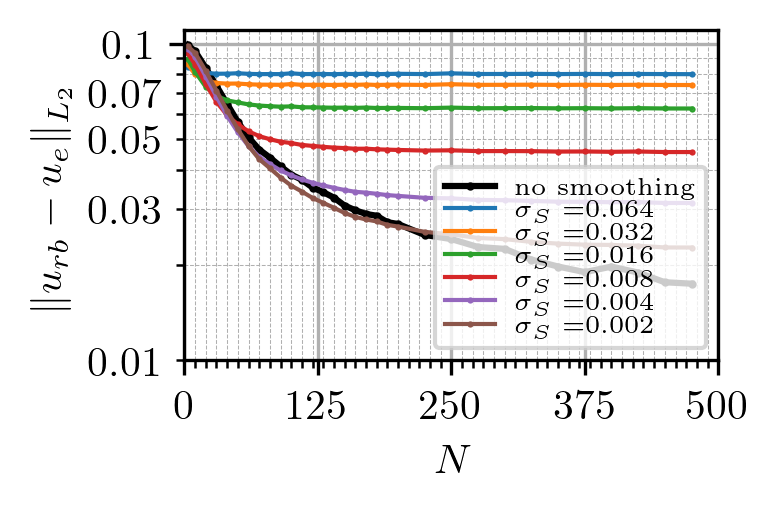

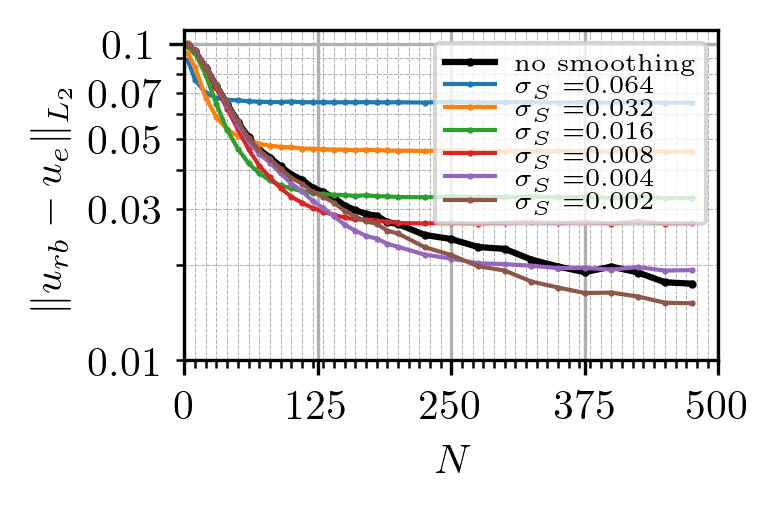

reduce to 1000 samples in x

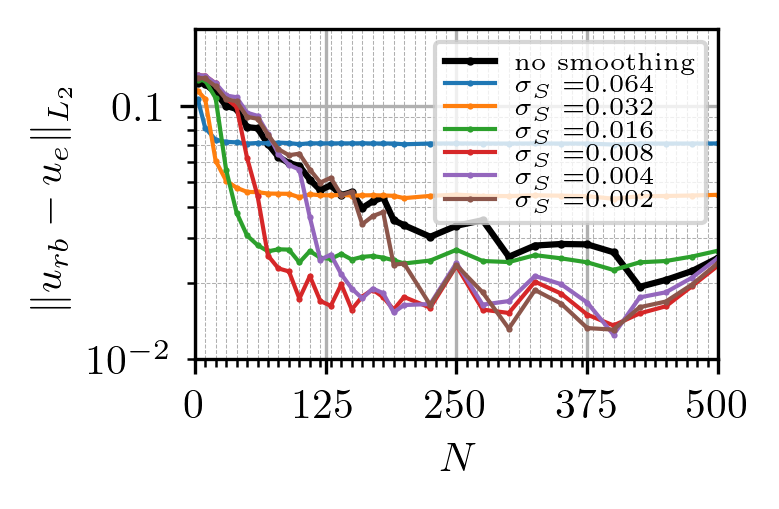

reduce to 10 test snapshots

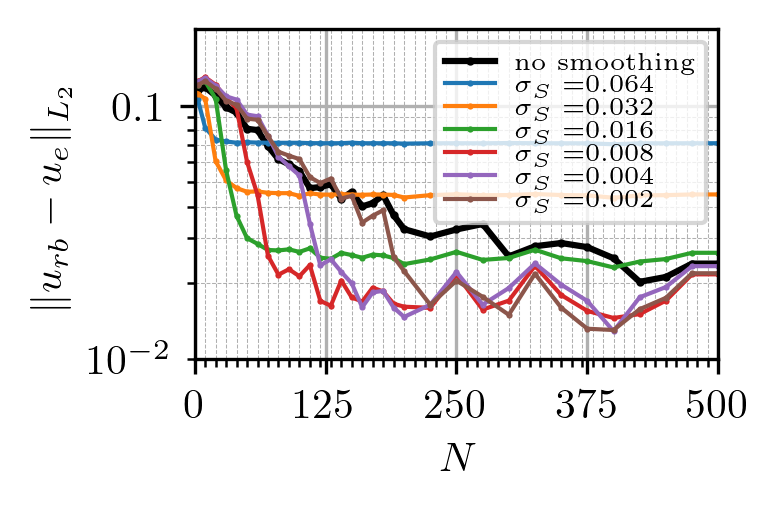

increase truncation of filter in deconvolution

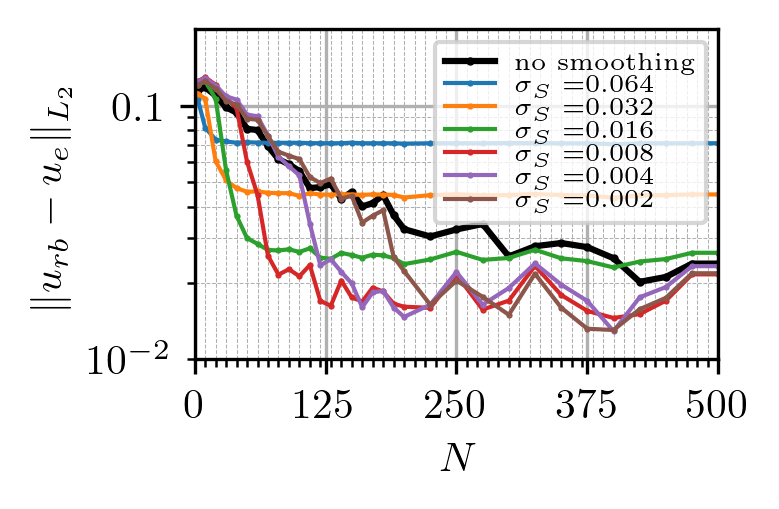

increase truncation in smoothing

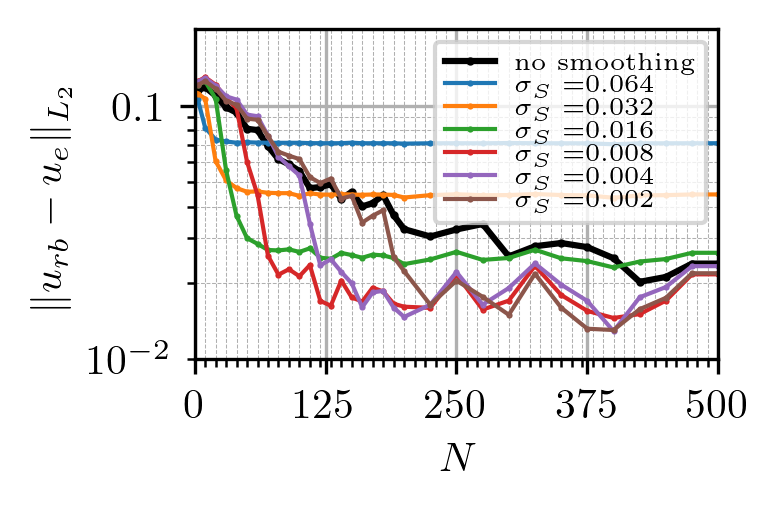

larger damping

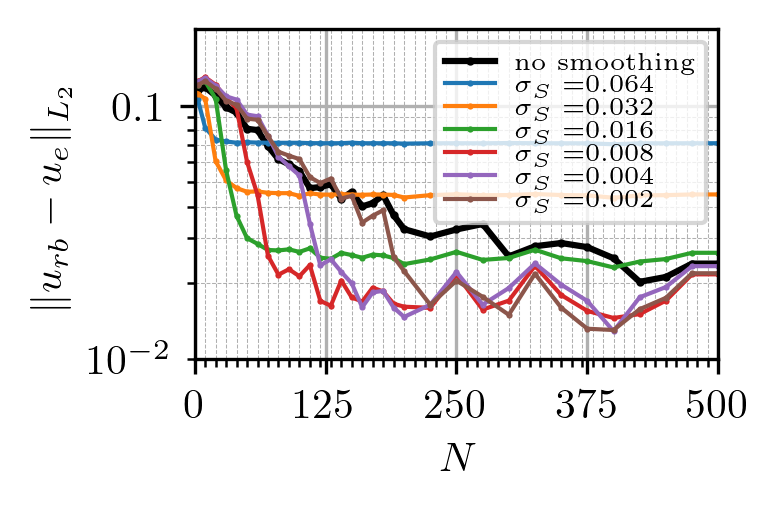

50 iterations, 5000 samples in x, damping = 1.2, truncate = 12

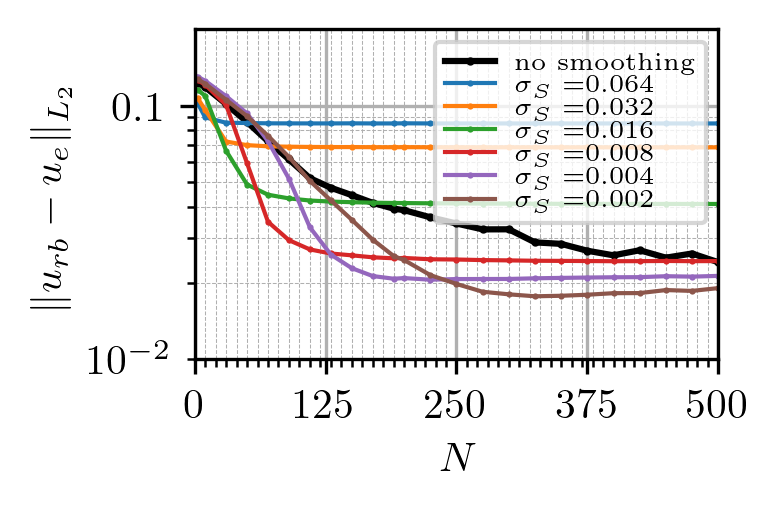


as sent to Kent (100 iterations, 5000 samples in x, damping = 2, truncate = 12, 25 test snapshots, pulse width=0.01)

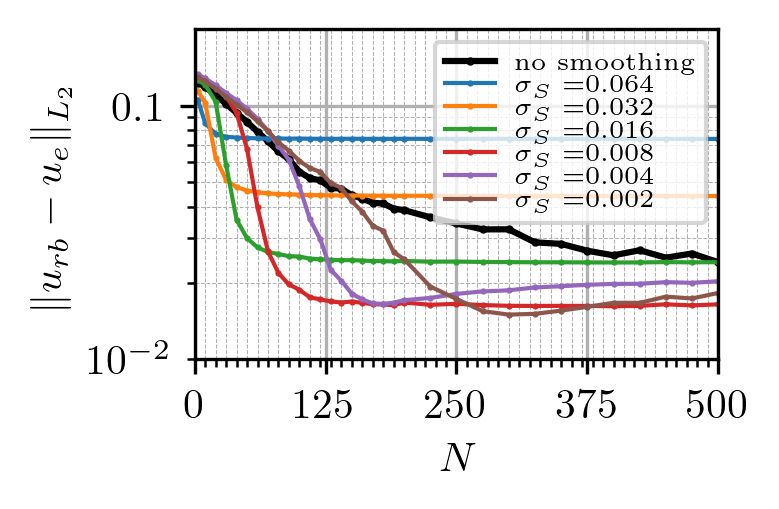

random snapshots:

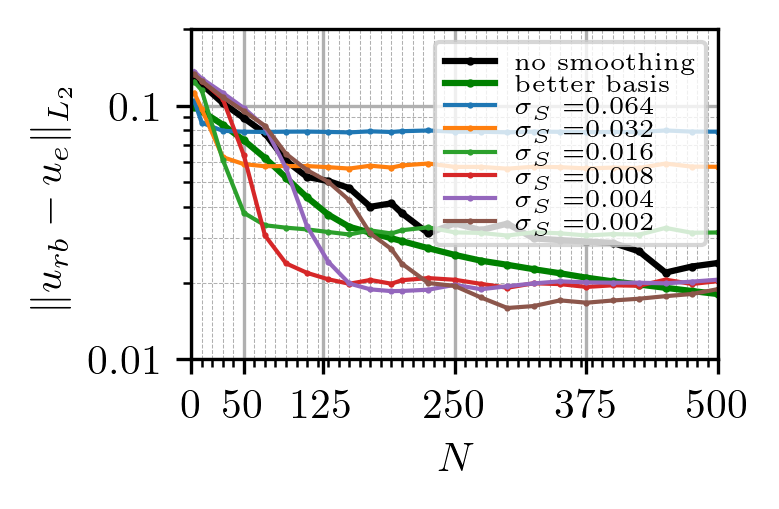


In [32]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
np.save(pth+"/dN.npy", dN)
np.save(pth+"/NN2.npy", NN)
np.save(pth+"/dN_ROM.npy", dN_ROM)
np.save(pth+"/dN_ROMi.npy", dN_ROMi)
np.save(pth+"/dN_sig_sROM.npy", dN_sig_sROM)
np.save(pth+"/dN_sig_dsROM.npy", dN_sig_dsROM)

dN = np.load(pth+"/dN.npy")
NN = np.load(pth+"/NN2.npy")
dN_ROM = np.load(pth+"/dN_ROM.npy")
dN_ROMi = np.load(pth+"/dN_ROMi.npy")
dN_sig_sROM = np.load(pth+"/dN_sig_sROM.npy")
dN_sig_dsROM = np.load(pth+"/dN_sig_dsROM.npy")

#sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])

In [33]:
dN.shape, NN.shape, dN_ROM.shape, dN_ROMi.shape, dN_sig_sROM.shape
#sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])

((2500,), (24,), (24,), (24,), (24, 6))

C:\Users\florianma\AppData\Local\Temp\ipykernel_132248\3466781489.py:2: RuntimeWarning: divide by zero encountered in divide
  decay_estimate = .5/N**.5
C:\Users\florianma\AppData\Local\Temp\ipykernel_132248\3466781489.py:6: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


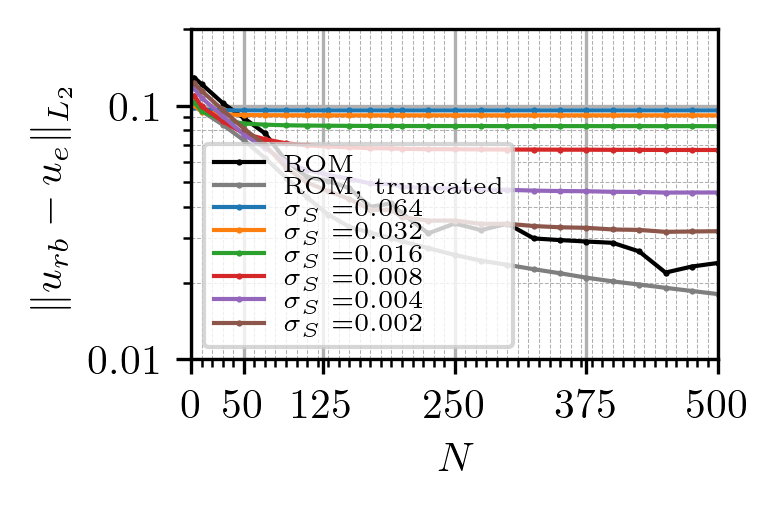

C:\Users\florianma\AppData\Local\Temp\ipykernel_132248\3466781489.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"standard ROM")


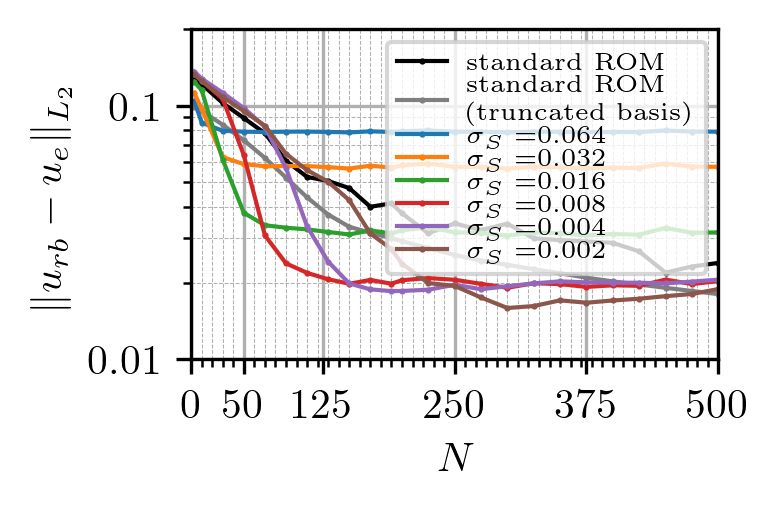

In [42]:
N = np.arange(len(dN))
decay_estimate = .5/N**.5


fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN, dN_sig_sROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.02, 0.2)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 50, 125, 250, 375, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)
plt.show()

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.07, 0.2)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 50, 125, 250, 375, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)

plt.show()

In [14]:
g = case["g"]

shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
#NN = np.array([*np.arange(4, 30, 2), *np.arange(30, 150, 10)])
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
dN_ROM = np.zeros(len(NN))
dN_sig = np.zeros((len(NN), 10))

sig = np.zeros((len(NN), 10))
sig[:, 1] = .05/NN**.5
sig[:, 2] = .01/NN**.5
sig[:, 3] = .001/NN**.5
#sig[:, 3] = .4 / (NN)
sig[:, 4] = .3 / (NN)
sig[:, 5] = .2 / (NN)   # this is the one for narrow saw tooth
sig[:, 6] = .1 / (NN)
sig[:, 7] = 10 / (NN**2)
sig[:, 8] = 25 / (NN**2)
sig[:, 9] = 40 / (NN**2)
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = rank
    case["n_train"] = n_train
    case["sROM_only"] = True
    
    parameters = optimize_sROM(case)
    sig[i, 0] = parameters[0]
    #sig[i, 0] = 0.02995521

    #for sigS, dN in zip([sig_opt, sig_1, sig_2, sig_3, sig_4], [dN_sig_opt, dN_sig_1, dN_sig_2, dN_sig_3, dN_sig_4]):
    for j in range(10):
        case["sigma"] = sig[i, j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig[i, j] = mean_sROM
        
    dN_ROM[i] = mean_ROM
np.save("./8_dN_ROM.npy", dN_ROM)
np.save("./8_dN_sig.npy", dN_sig)
np.save("./8_sig.npy", sig)
np.save("./8_NN.npy", NN)

3
max: 0.06666666666666667


ValueError: One of the requested xi is out of bounds in dimension 0

log log plot
plot sig S opt


In [ ]:
sigma_S

In [ ]:
# l = NN<70
# dN_sig[l, 5]

# from scipy.optimize import curve_fit

# def exp_func(x, a, b):
#     return a * np.exp(-b * x)  # No offset (simpler form)

# popt, pcov = curve_fit(exp_func, NN[l], dN_sig[l, 5], p0=(1/12, 300))  # Initial guess: (a=1, b=0.1)
# a_fit, b_fit = popt  # Extract fitted parameters
# print(popt)
# a_fit, b_fit = 1/12, 300
# plt.plot(NN[l], dN_sig[l, 5], "C0x")
# #plt.plot(NN, exp_func(NN, a_fit, b_fit))

In [ ]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
#plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, np.exp(-NN/300)/12, "C3--", lw=1, ms=1, label=r"$exp(-N)$")
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()


ax.set_yscale("log")
plt.xlim(0, 100)
plt.ylim(0.03, 0.11)


ax.set_xticks(np.linspace(0, 100, 11, endpoint=True), minor=True)
ax.set_xticks([0, 50, 100], minor=False)

ax.set_yticks(np.linspace(0.03, 0.1, 8, endpoint=True), minor=True)
ax.set_yticks([0.1], minor=False)
ax.set_yticklabels(["0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
# ax.set_yticks([0.03, 0.05, 0.06, 0.1], minor=False)
#ax.set_yticklabels(["0.03", "0.04", "0.06", "0.1"], minor=True)
ax.set_yticklabels(["0.1"], minor=False)




#ax.set_yticks(np.linspace(0.01, 0.1, 10, endpoint=True), minor=True)
#ax.set_yticklabels(["0.01", "0.1" ], minor=False)
#ax.set_yticklabels(["0.01", "0.02", "0.03"," 0.04", "0.05", "0.06", "0.07", "0.08", "0.09", "0.1" ], minor=True)
print(ax.get_yticks(minor=True))
print(ax.get_yticks(minor=False))
print(ax.get_yticklabels(minor=True))

# fmt = lambda x, pos: '{:.2f}'.format(x, pos)
# ax.yaxis.set_minor_formatter(mpl.ticker.FuncFormatter(fmt))
# ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(fmt))

plt.show()






fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.-", ms=2, label="no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")# r"$u_{\mu,Srb}$"

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 500)
plt.ylim(1e-2, 0.11)
plt.show()

In [ ]:
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, sig[:, i], "o", ms=2, label=lbls[i])
plt.plot(NN, sig[:, 0], "x", ms=3, label=r"optimized $\sigma_S$")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 0.032)
plt.xlabel("$N$")
plt.ylabel(r"$\sigma_S$")